## ARCH 過程

ARCH(1) 過程は以下のように定義される。$$\begin{gather*}\varepsilon_t = \sigma_t v_t, \qquad v_t \sim N(0,1) \\[8px] \sigma_t^2 = \alpha_0 + \alpha_1 \varepsilon_{t-1}^2 \end{gather*}$$ここで $\alpha_0 > 0, \alpha_1 \geq 0$ が条件付き分散の非負性のための制約であり、定常性のためには $\alpha_1 < 1$ が必要である。条件なし分散は $Var(\varepsilon_t) = \mathbb{E}[\varepsilon_t^2] = \frac{\alpha_0}{1-\alpha_1}$ で与えられる。

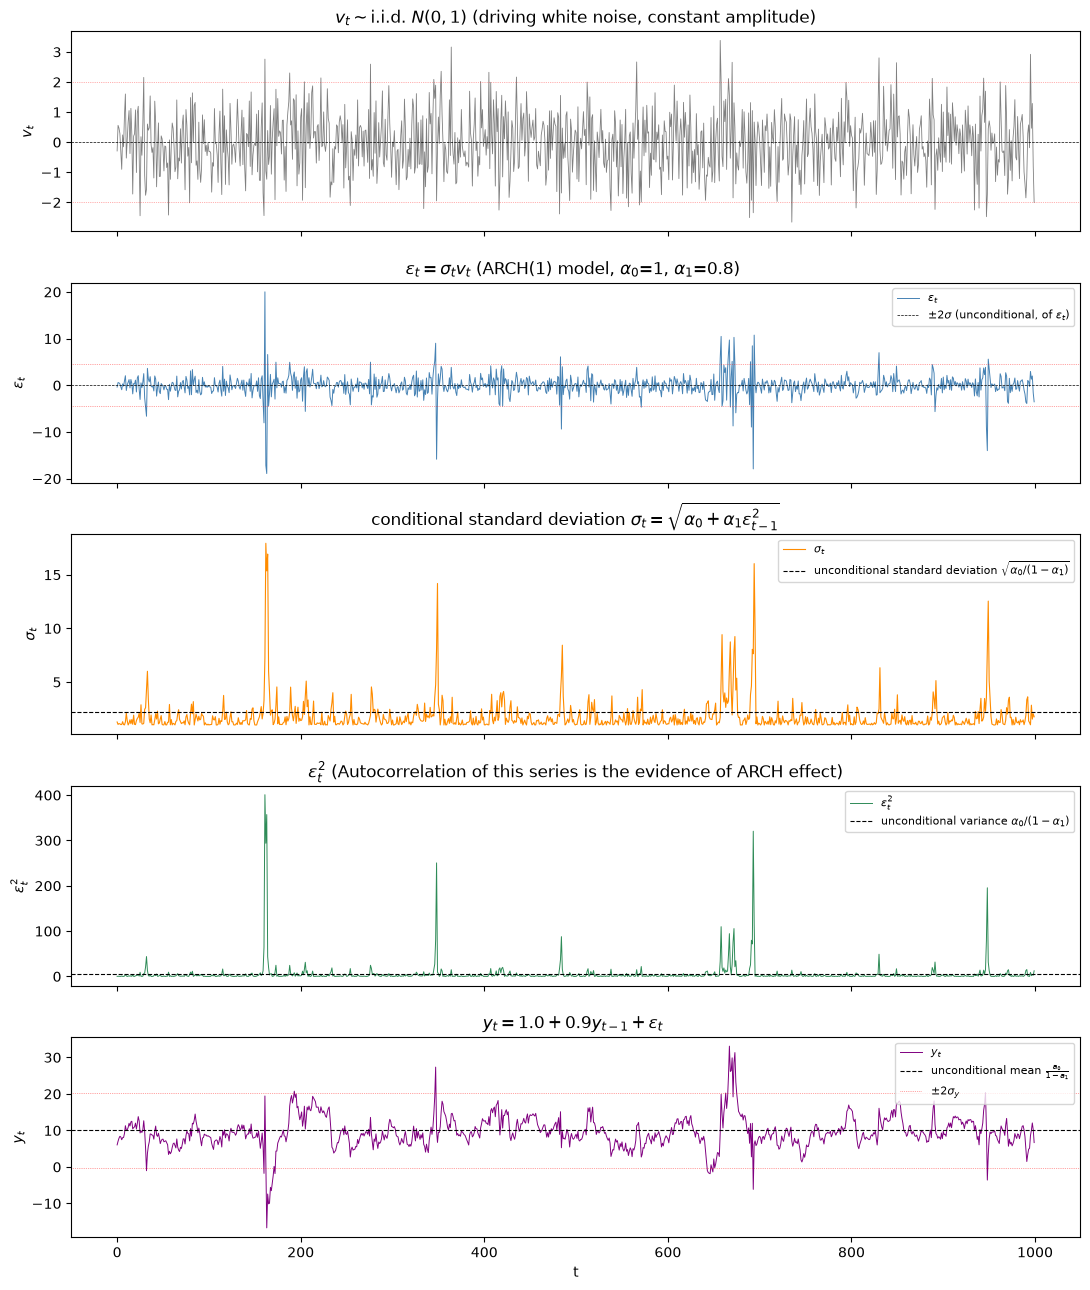

unconditional variance of epsilon_t under the theoretical model: 5.0000
sample variance of epsilon_t: 5.6687
first-order autocorrelation coefficient of epsilon_t^2: 0.5877
unconditional mean of y_t: 10.0000
sample mean of y_t: 9.5855
--- white noise v_t diagnostics ---
sample mean of v_t: -0.0182 (theoretical: 0)
sample variance of v_t: 1.0055 (theoretical: 1)
sample autocorrelation of v_t: -0.0414 (theoretical: 0)
sample autocorrelation of v_t^2: 0.0269 (theoretical: 0, ARCH effect only in epsilon)


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from arch.univariate import ARCH, ARX, ConstantMean, Normal

np.random.seed(42)

# ARCH(1) パラメータ
a0 = 1.0
a1 = 0.9
alpha0 = 1
alpha1 = 0.8
n = 1000

# モデル定義：y_t = a0 +a1 * y_{t-1} + epsilon_t, epsilon_t = sigma_t * v_t
model = ARX(y=None, lags=1)  # AR(1) モデルの定義
model.volatility = ARCH(p=1)
model.distribution = Normal()

# パラメータを [a0, a1, alpha0, alpha1] の順で設定
sim_data = model.simulate(params=[a0, a1, alpha0, alpha1], nobs=n, burn=200)

y = sim_data['data'].values  # 生成された系列 y_t
eps = sim_data['errors'].values  # 生成された系列 epsilon_t
sigma = sim_data['volatility'].values  # 条件付き標準偏差 sigma_t
sigma2 = sigma**2  # 条件付き分散 sigma_t^2
v = eps / sigma  # ホワイトノイズ v_t = epsilon_t / sigma_t を復元
time = np.arange(n)

# 理論的な無条件分散
uncond_var_eps = alpha0 / (1 - alpha1)  # epsilon_t の無条件分散
uncond_std_eps = np.sqrt(uncond_var_eps)  # epsilon_t の無条件標準偏差
uncond_mean_y = a0 / (1 - a1)  # y_t の無条件平均
uncond_var_y = uncond_var_eps / (1 - a1**2)  # y_t の無条件分散
uncond_std_y = np.sqrt(uncond_var_y)  # y_t の無条件標準偏差

# --- プロット ---
fig, axes = plt.subplots(5, 1, figsize=(11, 13), sharex=True)  # sharex=True で x 軸を共有

# 0. ホワイトノイズ v_t（波及の出発点）
axes[0].plot(time, v, color='gray', linewidth=0.6)
axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[0].axhline(2, color='red', linewidth=0.5, linestyle=':', alpha=0.6)
axes[0].axhline(-2, color='red', linewidth=0.5, linestyle=':', alpha=0.6)
axes[0].set_title(r'$v_t \sim \text{i.i.d. } N(0,1)$ (driving white noise, constant amplitude)')
axes[0].set_ylabel(r'$v_t$')

# 1. epsilon_t = sigma_t * v_t（修正: 境界線をepsilon_tの無条件標準偏差に修正）
axes[1].plot(time, eps, color='steelblue', linewidth=0.7)
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].axhline(2*uncond_std_eps, color='red', linewidth=0.5, linestyle=':', alpha=0.7)
axes[1].axhline(-2*uncond_std_eps, color='red', linewidth=0.5, linestyle=':', alpha=0.7)
axes[1].set_title(r'$\epsilon_t = \sigma_t v_t$ (ARCH(1) model, $\alpha_0$={}, $\alpha_1$={}) '.format(alpha0, alpha1))
axes[1].set_ylabel(r'$\epsilon_t$')
axes[1].legend([r'$\epsilon_t$', r'$\pm 2\sigma$ (unconditional, of $\epsilon_t$)'], loc='upper right', fontsize=8)

# 2. conditional standard deviation sigma_t
axes[2].plot(time, sigma, color='darkorange', linewidth=0.8)
axes[2].axhline(uncond_std_eps, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title(r'conditional standard deviation $\sigma_t = \sqrt{\alpha_0 + \alpha_1 \epsilon_{t-1}^2}$')
axes[2].set_ylabel(r'$\sigma_t$')
axes[2].legend([r'$\sigma_t$', r'unconditional standard deviation $\sqrt{\alpha_0/(1-\alpha_1)}$'], loc='upper right', fontsize=8)

# 3. epsilon_t^2
axes[3].plot(time, eps**2, color='seagreen', linewidth=0.7)
axes[3].axhline(uncond_var_eps, color='black', linewidth=0.8, linestyle='--')
axes[3].set_title(r'$\epsilon_t^2$ (Autocorrelation of this series is the evidence of ARCH effect)')
axes[3].set_ylabel(r'$\epsilon_t^2$')
axes[3].legend([r'$\epsilon_t^2$', r'unconditional variance $\alpha_0/(1-\alpha_1)$'], loc='upper right', fontsize=8)

# 4. y_t = a0 + a1 * y_{t-1} + epsilon_t
axes[4].plot(time, y, color='purple', linewidth=0.7)
axes[4].axhline(uncond_mean_y, color='black', linewidth=0.8, linestyle='--')
axes[4].axhline(uncond_mean_y + 2*uncond_std_y, color='red', linewidth=0.5, linestyle=':', alpha=0.7)
axes[4].axhline(uncond_mean_y - 2*uncond_std_y, color='red', linewidth=0.5, linestyle=':', alpha=0.7)
axes[4].set_title(r'$y_t = {} + {} y_{{t-1}} + \epsilon_t$ '.format(a0, a1))
axes[4].set_xlabel('t')
axes[4].set_ylabel(r'$y_t$')
axes[4].legend([r'$y_t$', r'unconditional mean $\frac{a_0}{1-a_1}$', r'$\pm 2\sigma_y$'], loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

print(f"unconditional variance of epsilon_t under the theoretical model: {uncond_var_eps:.4f}")
print(f"sample variance of epsilon_t: {np.var(eps):.4f}")
print(f"first-order autocorrelation coefficient of epsilon_t^2: {np.corrcoef(eps[:-1]**2, eps[1:]**2)[0,1]:.4f}")
print(f"unconditional mean of y_t: {uncond_mean_y:.4f}")
print(f"sample mean of y_t: {np.mean(y):.4f}")
print("--- white noise v_t diagnostics ---")
print(f"sample mean of v_t: {np.mean(v):.4f} (theoretical: 0)")
print(f"sample variance of v_t: {np.var(v):.4f} (theoretical: 1)")
print(f"sample autocorrelation of v_t: {np.corrcoef(v[:-1], v[1:])[0,1]:.4f} (theoretical: 0)")
print(f"sample autocorrelation of v_t^2: {np.corrcoef(v[:-1]**2, v[1:]**2)[0,1]:.4f} (theoretical: 0, ARCH effect only in epsilon)")

### Appendix

#### 「条件付き」とは

「条件付き」とは、過去の情報集合 $\mathcal{F}_{t-1}$ を所与としたうえでの、という意味であるので条件付き平均・条件付き分散はそれぞれ$$\mu_t \equiv \mathbb{E}[y_t|\mathcal{F}_{t-1}], \qquad \sigma_t^2 \equiv Var(y_t|\mathcal{F}_{t-1}) = \mathbb{E}[(y_t - \mu_t)^2|\mathcal{F}_{t-1}]$$と定義される。つまり「過去のデータを知っているという前提のもとで、次の期の $y_t$ がどんな確率分布に従うと予想されるか」を表す。  
<br>  
一方、無条件平均・無条件分散は、過去の情報を一切使わず、系列全体を通じた長期的・平均的な性質を表す。$$\mu \equiv \mathbb{E}[y_t], \qquad \sigma^2 \equiv Var(y_t)$$これらは（定常性のもとでは） $t$ に依存しない定数である。  
<br>  
天気予報で例えると、無条件の降水確率は「この地域の年間の降水確率は平均して30％です」というようなもので場所固有の気候的性質であり、時間に依存していない。条件付きの降水確率は「今日の気圧配置と昨日までの気象データを踏まえると、明日の降水確率は80％です」という直近の情報を使った、その日ごとに変わる予測である。  
ARCHの文脈で言えば、無条件分散 $\mathbb{E}[\varepsilon_t^2] = \frac{\alpha_0}{1-\alpha_1}$ は「このリターン系列は、長期的に見れば平均してこれくらいの変動幅を持つ」という、系列全体の性質であり、条件付き分散 $\mathbb{E}[\varepsilon_t^2|\mathcal{F}_{t-1}] = \alpha_0 + \alpha_1 \varepsilon_{t-1}^2$ は「昨日大きな値動きがあったことを踏まえると、今日はこれくらいの変動幅が予想される」という、直前の情報を使った1期先予測となる。したがって、予測に関して言えば無条件予測より条件付き予測のほうが優れている。